In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [30]:
df.shape

(7043, 21)

In [33]:
print("Duplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nNumerical Summary:")
display(df.describe())

print("\nChurn Distribution:")
display(df["Churn"].value_counts())

Duplicate Rows: 0

Unique Values:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Numerical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Churn Distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nTotal Charges Summary:")
display(df["TotalCharges"].describe())

Missing Values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [35]:
missing_total = df[df["TotalCharges"].isnull()]

print("Missing TotalCharges:", len(missing_total))
print("\nTenure of Missing Records:")
print(missing_total["tenure"].value_counts())

display(missing_total[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Missing TotalCharges: 11

Tenure of Missing Records:
tenure
0    11
Name: count, dtype: int64


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [36]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing Values After Cleaning:")
print(df.isnull().sum().sum())

print("\nDataset Shape:", df.shape)

display(df.head())

Missing Values After Cleaning:
0

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


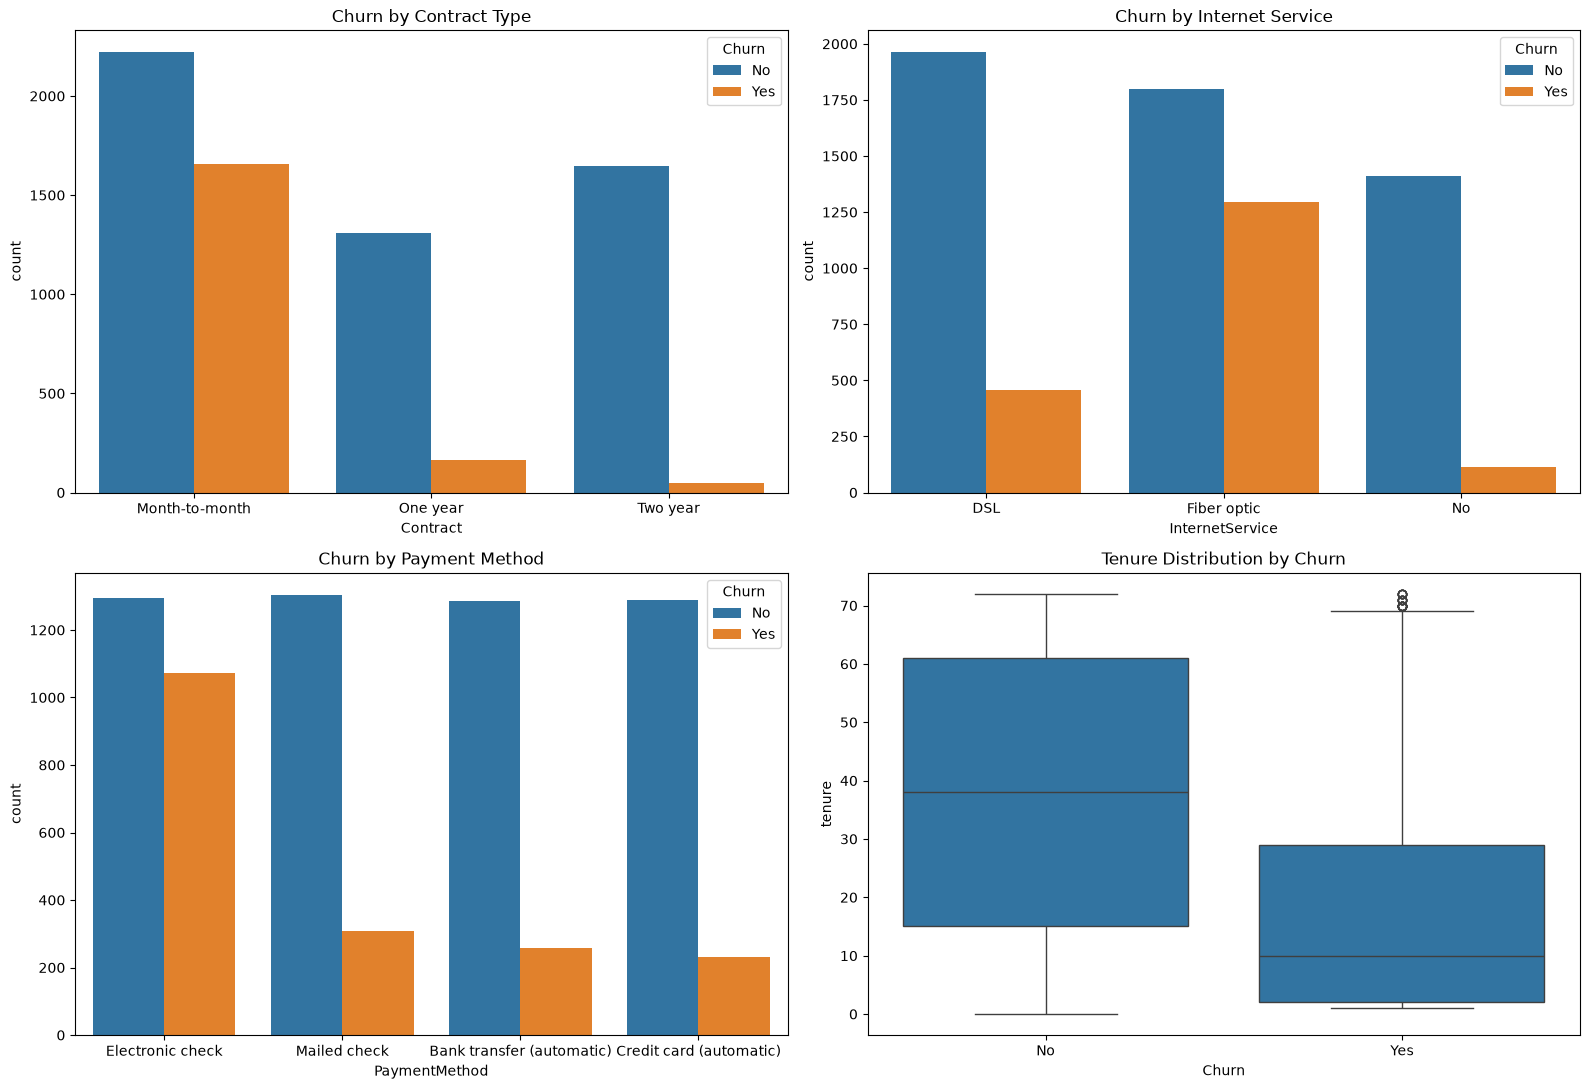

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 0])
sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0, 1])
sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[1, 0])
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1, 1])

axes[0, 0].set_title("Churn by Contract Type")
axes[0, 1].set_title("Churn by Internet Service")
axes[1, 0].set_title("Churn by Payment Method")
axes[1, 1].set_title("Tenure Distribution by Churn")

plt.tight_layout()
plt.show()

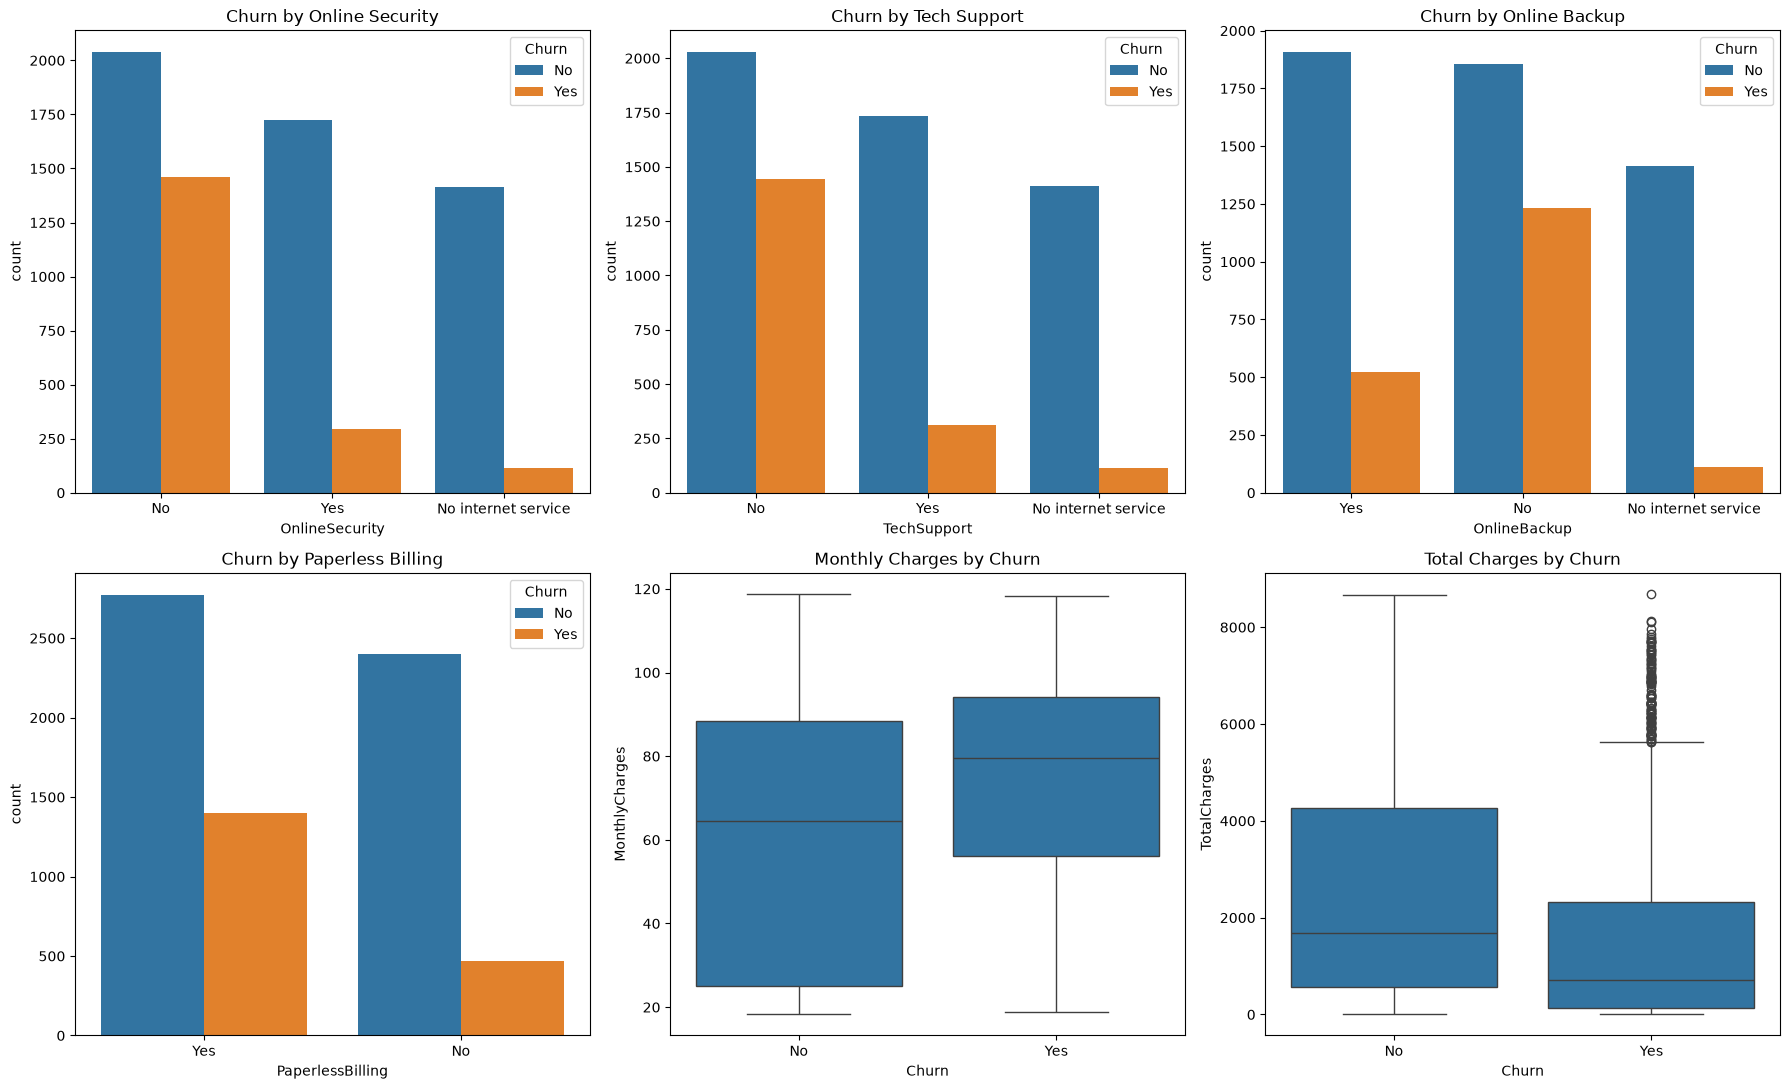

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn", ax=axes[0, 0])
sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[0, 1])
sns.countplot(data=df, x="OnlineBackup", hue="Churn", ax=axes[0, 2])
sns.countplot(data=df, x="PaperlessBilling", hue="Churn", ax=axes[1, 0])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 1])
sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[1, 2])

axes[0, 0].set_title("Churn by Online Security")
axes[0, 1].set_title("Churn by Tech Support")
axes[0, 2].set_title("Churn by Online Backup")
axes[1, 0].set_title("Churn by Paperless Billing")
axes[1, 1].set_title("Monthly Charges by Churn")
axes[1, 2].set_title("Total Charges by Churn")

plt.tight_layout()
plt.show()

In [39]:
for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "OnlineBackup", "PaperlessBilling"]:
    churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index")["Yes"] * 100
    print(f"\n{col}")
    print(churn_rate.round(2).sort_values(ascending=False))


Contract
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Yes, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Yes, dtype: float64

TechSupport
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Yes, dtype: float64

OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Yes, dtype: float64

PaperlessBilling
PaperlessBilling
Yes    33.57
No     16.33
Name: Yes, dtype: float64


In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
print("Features:", X.shape[1])

Training Data: (5634, 30)
Testing Data: (1409, 30)
Features: 30


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8041
Precision: 0.6541
Recall: 0.5561
F1 Score: 0.6012
ROC-AUC: 0.8426

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



C:\Users\shubh\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7743
Precision: 0.566
Recall: 0.6417
F1 Score: 0.6015
ROC-AUC: 0.8275

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.57      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [45]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7963
Precision: 0.6364
Recall: 0.5428
F1 Score: 0.5859
ROC-AUC: 0.8317

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8041,0.6541,0.5561,0.6012,0.8426
1,Random Forest,0.7743,0.5660,0.6417,0.6015,0.8275
2,XGBoost,0.7963,0.6364,0.5428,0.5859,0.8317


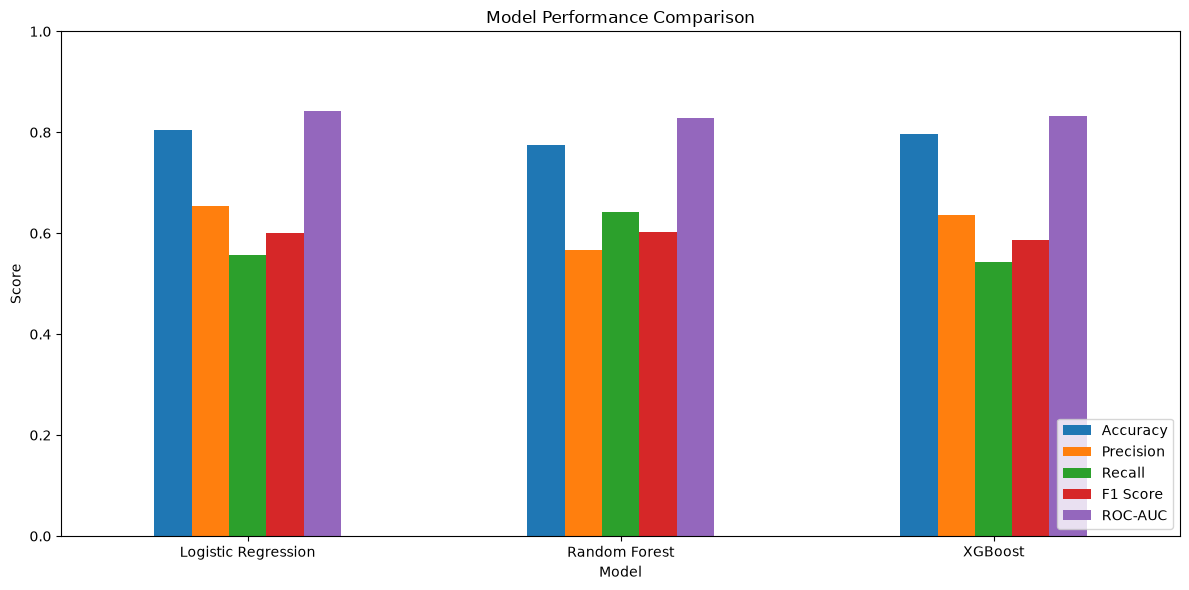

In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.8041, 0.7743, 0.7963],
    "Precision": [0.6541, 0.5660, 0.6364],
    "Recall": [0.5561, 0.6417, 0.5428],
    "F1 Score": [0.6012, 0.6015, 0.5859],
    "ROC-AUC": [0.8426, 0.8275, 0.8317]
})

display(results)

results.set_index("Model").plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

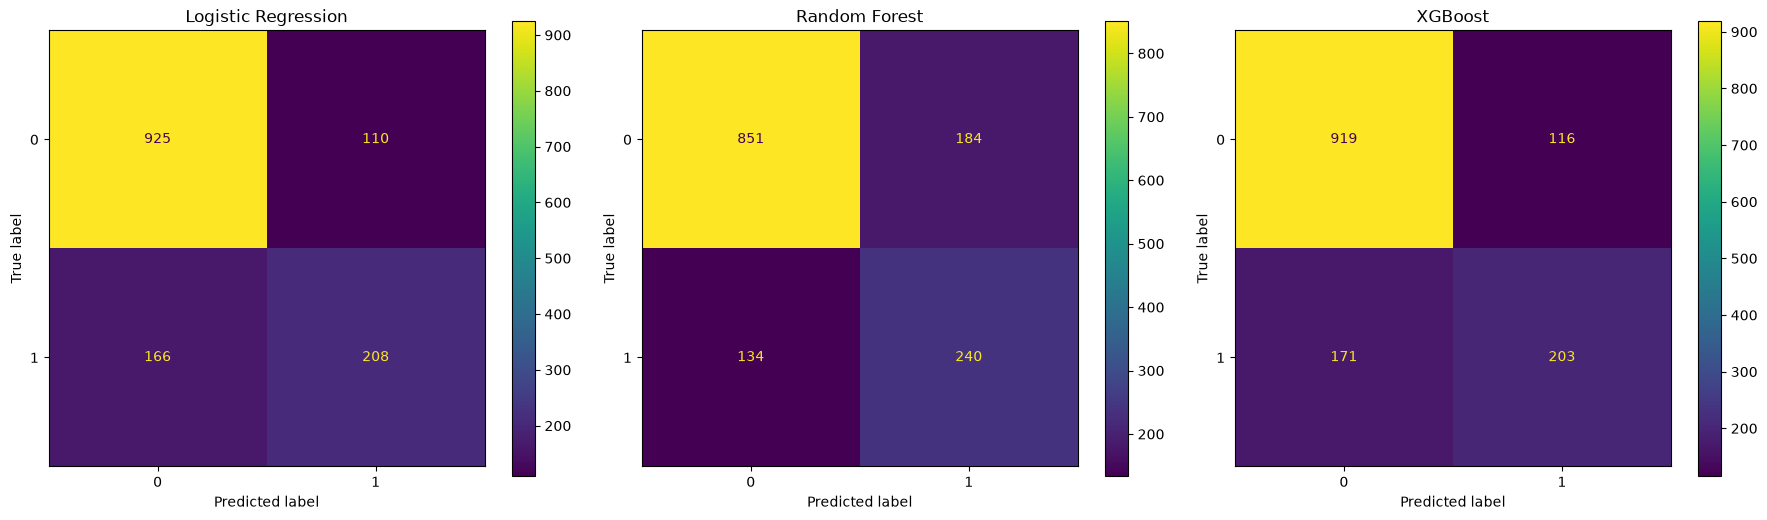

<Figure size 900x700 with 0 Axes>

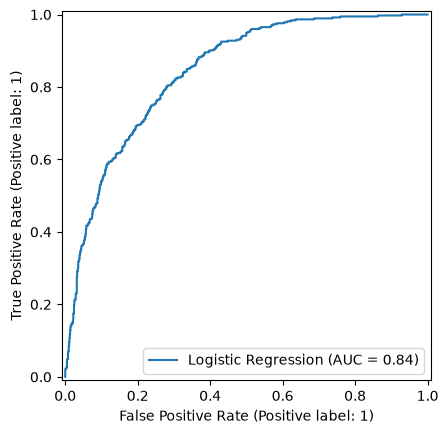

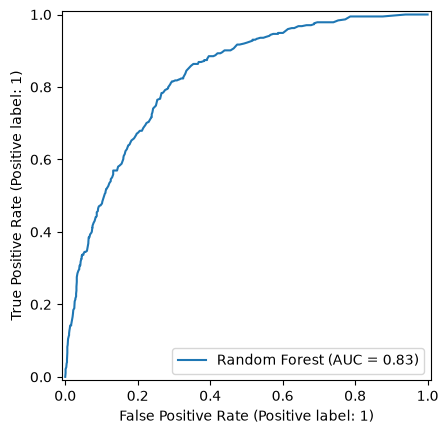

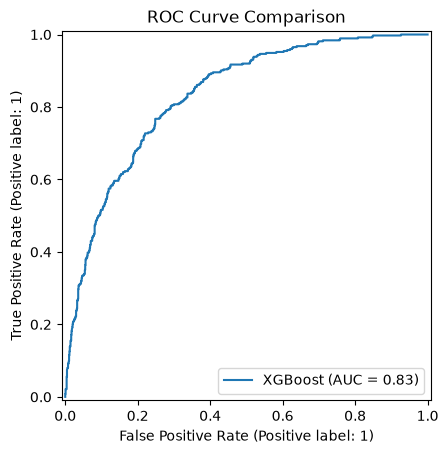

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[2])
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost")

plt.title("ROC Curve Comparison")
plt.show()

TotalCharges                      0.176915
tenure                            0.165664
MonthlyCharges                    0.151647
Contract_Two year                 0.058577
InternetService_Fiber optic       0.043664
PaymentMethod_Electronic check    0.037028
Contract_One year                 0.029995
OnlineSecurity_Yes                0.028289
gender_Male                       0.025872
PaperlessBilling_Yes              0.023761
TechSupport_Yes                   0.022197
Partner_Yes                       0.020944
OnlineBackup_Yes                  0.020302
Dependents_Yes                    0.019179
DeviceProtection_Yes              0.017923
dtype: float64

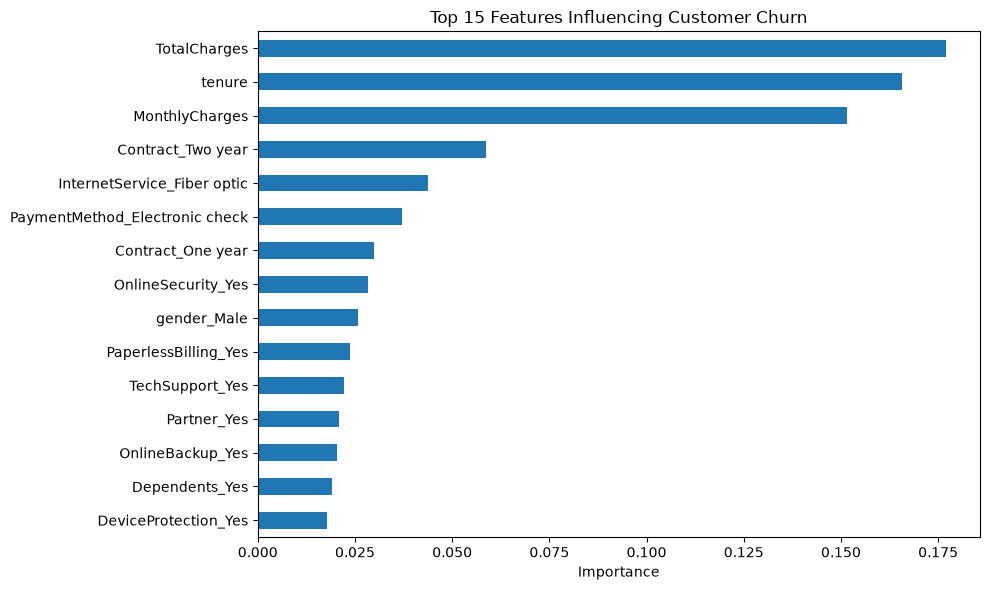

In [49]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

tenure_group
0-12     47.44
13-24    28.71
25-36    21.63
37-48    19.03
49-60    14.42
61-72     6.61
Name: Churn, dtype: float64


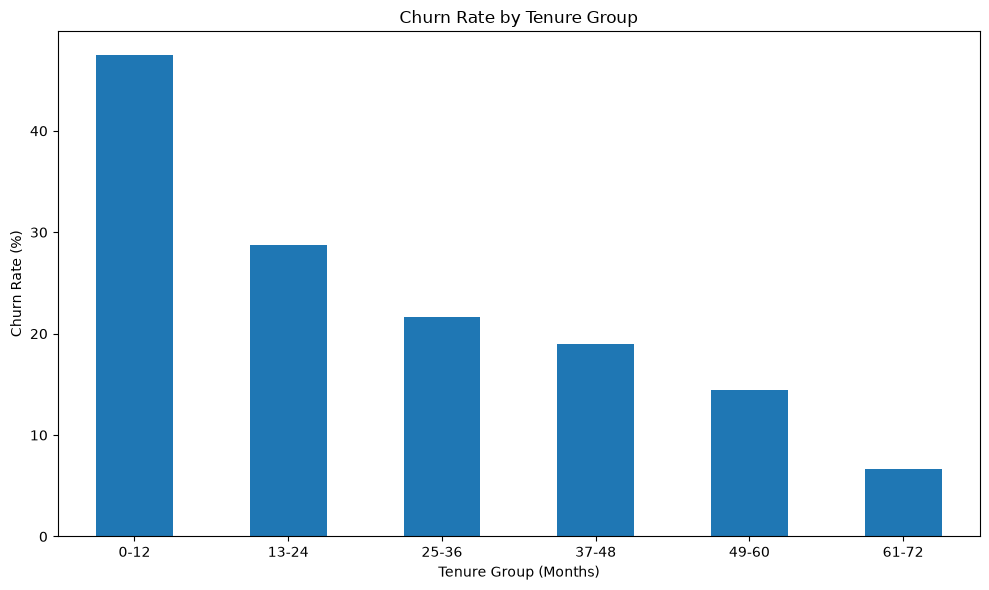

In [50]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"],
    include_lowest=True
)

tenure_churn = df.groupby("tenure_group", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_churn.round(2))

plt.figure(figsize=(10, 6))
tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8041,0.6541,0.5561,0.6012,0.8426
2,XGBoost,0.7963,0.6364,0.5428,0.5859,0.8317
1,Random Forest,0.7743,0.5660,0.6417,0.6015,0.8275


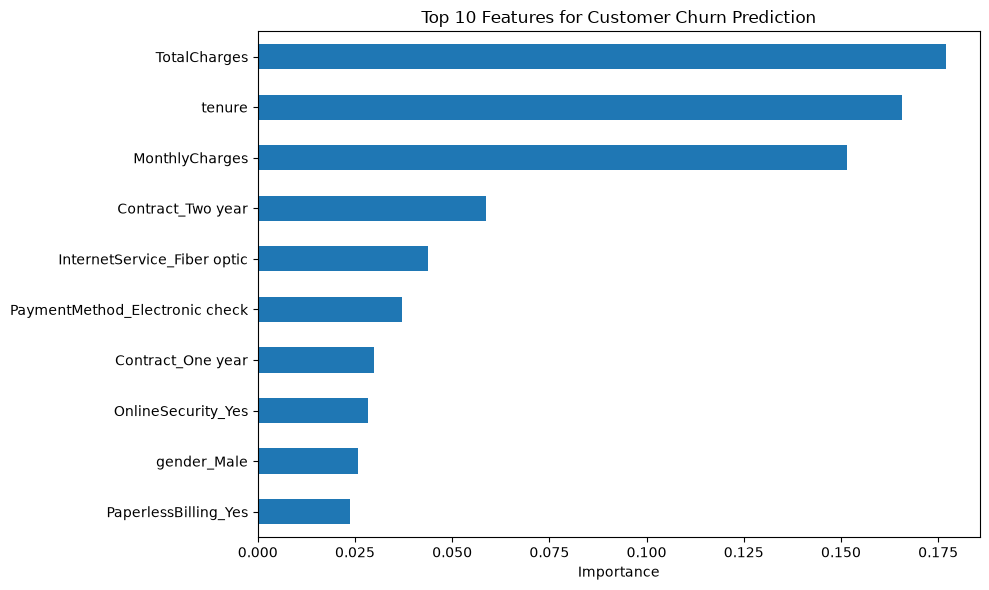

In [51]:
final_results = results.sort_values("ROC-AUC", ascending=False)

display(final_results)

plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features for Customer Churn Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [52]:
predictions = df.loc[X_test.index, ["customerID"]].copy()

predictions["Actual_Churn"] = y_test
predictions["Predicted_Churn"] = y_pred_lr
predictions["Churn_Probability"] = y_prob_lr

predictions["Risk_Level"] = pd.cut(
    predictions["Churn_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

predictions = predictions.sort_values(
    "Churn_Probability",
    ascending=False
)

display(predictions.head(20))

print("Total Customers Predicted:", len(predictions))
print("High-Risk Customers:", (predictions["Risk_Level"] == "High Risk").sum())

predictions.to_csv("customer_churn_predictions.csv", index=False)

,customerID,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
3380,5178-LMXOP,1,1,0.854991,High Risk
6866,0295-PPHDO,1,1,0.832970,High Risk
6365,8884-ADFVN,1,1,0.827226,High Risk
2631,6861-XWTWQ,1,1,0.825159,High Risk
3727,9057-SIHCH,1,1,0.822282,High Risk
4585,1069-XAIEM,1,1,0.819831,High Risk
2797,6023-YEBUP,1,1,0.819688,High Risk
6894,1400-MMYXY,1,1,0.818574,High Risk
3346,2545-EBUPK,0,1,0.815414,High Risk
4039,8161-QYMTT,0,1,0.808245,High Risk


Total Customers Predicted: 1409
High-Risk Customers: 210


In [53]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [90.00],
    "TotalCharges": [450.00]
})

new_customer_encoded = pd.get_dummies(new_customer, drop_first=True)
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

new_prediction = model_lr.predict(new_customer_encoded)[0]
new_probability = model_lr.predict_proba(new_customer_encoded)[0, 1]

print("Predicted Churn:", "Yes" if new_prediction == 1 else "No")
print("Churn Probability:", round(new_probability * 100, 2), "%")

if new_probability >= 0.6:
    print("Risk Level: High Risk")
elif new_probability >= 0.3:
    print("Risk Level: Medium Risk")
else:
    print("Risk Level: Low Risk")

Predicted Churn: No
Churn Probability: 43.41 %
Risk Level: Medium Risk
